In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import uncertainities_utilities as tp
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr

/opt/anaconda3/lib/python3.13/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [ ]:
# Setting duration of data and input time of signal to be recovered.

duration = 4
input_time = 2

In [ ]:
# Generating a bunch of noise to inject signals into.

np.random.seed(1234)
psd = tp.psd(duration)
noise = [tp.noise(duration, input_psd = psd) for _ in range(10000)]


In [ ]:
N_train = 50   # number of random training waveforms
N_val = 20     # number of random validation waveforms

mass_range = (5, 80)      # allowed mass range (solar masses)
distance_range = (100, 6000)  # Mpc


# Generate random component masses where m1 >= m2. Using uniform distribution for simplicity. Could swap to other distributions if desired.

def random_mass_pair(m_min, m_max):
    m1, m2 = np.random.uniform(m_min, m_max, 2)
    return max(m1, m2), min(m1, m2)

# Generate random distance. USing unifrom distribution for simplicity. Coud swap to other distributions if desired.

def random_distance(d_min, d_max):
    return np.random.uniform(d_min, d_max)

# Generate training and validation waveforms with varied parameters.

def generate_waveform_batch(num, prefix):
    wf_dict = {}
    for i in range(num):
        m1, m2 = random_mass_pair(*mass_range)
        d = random_distance(*distance_range)

        key = f"{prefix}_{int(m1)}_{int(m2)}_{int(d)}"
        try:
            wf = tp.waveform(noise[0], m1, m2, d)
            wf_dict[key] = wf
        except Exception as e:
            print(f"Failed to generate {key}: {e}")

    return wf_dict


training_wfs = generate_waveform_batch(N_train, prefix="train")
validation_wfs = generate_waveform_batch(N_val, prefix="val")

print(f"Generated {len(training_wfs)} training waveforms.")
print(f"Generated {len(validation_wfs)} validation waveforms.")

Generated 50 training waveforms.
Generated 20 validation waveforms.


In [ ]:
# Organize training and validation results into sorted arrays

training_results = tp.compute_results_for_sets(noise, training_wfs, input_time, duration)
training_arrays = tp.sorted_arrays_from_results(training_results)
training_arrays = tp.apply_datacuts_to_dict(training_arrays)

validation_results = tp.compute_results_for_sets(noise, validation_wfs, input_time, duration)
validation_arrays = tp.sorted_arrays_from_results(validation_results)
validation_arrays = tp.apply_datacuts_to_dict(validation_arrays)

# Combine all training data into single arrays for analysis

all_t = np.concatenate([t for (t,_,_,_) in training_arrays.values()])
all_p = np.concatenate([p for (_,p,_,_) in training_arrays.values()])
all_s = np.concatenate([s for (_,_,s,_) in training_arrays.values()])
all_snr = np.concatenate([snr for (_,_,_,snr) in training_arrays.values()])

In [ ]:
# Perform Pearson r test of correlation between uncertainties

print(pearsonr(all_p, all_t))
print(pearsonr(all_s, all_p))
print(pearsonr(all_s, all_t))

correlation coefficient between p and t: 0.8616291441937292
PearsonRResult(statistic=np.float64(0.8616291441937269), pvalue=np.float64(0.0))
PearsonRResult(statistic=np.float64(-0.00040761976823552133), pvalue=np.float64(0.7791932167992403))
PearsonRResult(statistic=np.float64(-6.746933252015915e-05), pvalue=np.float64(0.9629858503073782))


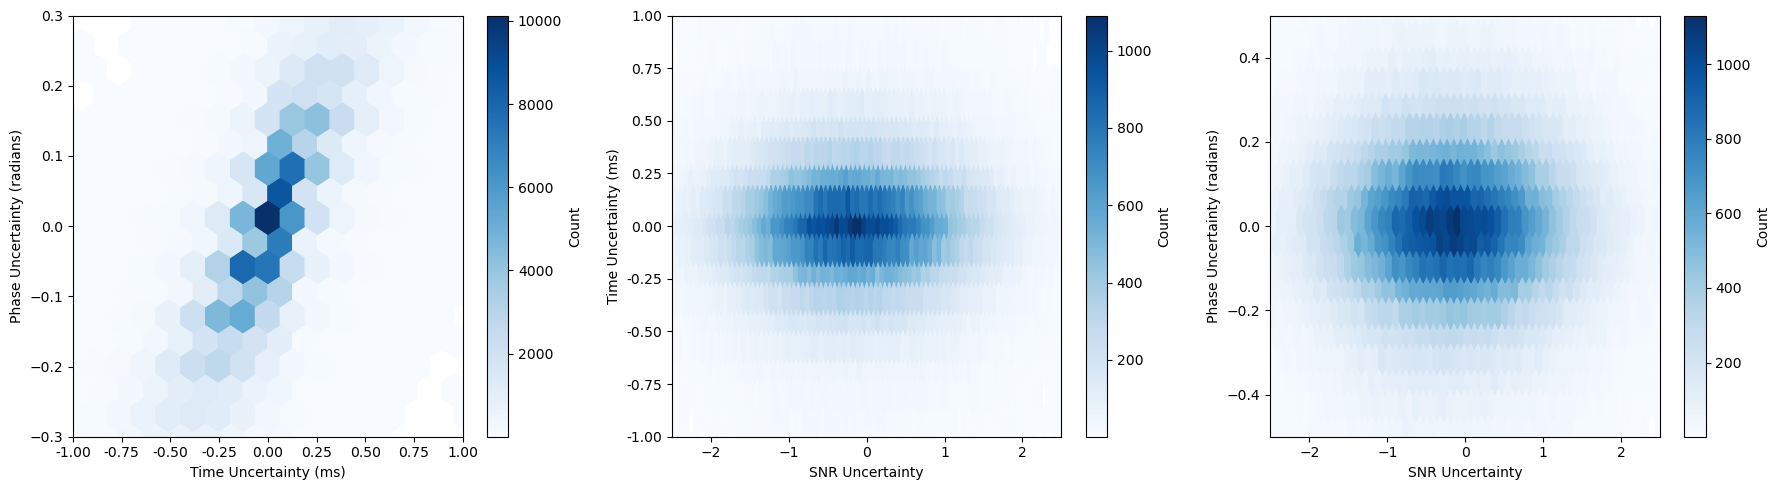

In [ ]:
# Hexbin plots for uncertainty correlations

# Remove high SNR points for better visualization

all_t = np.delete(all_t, np.where(all_snr > 20))
all_p = np.delete(all_p, np.where(all_snr > 20))
all_s = np.delete(all_s, np.where(all_snr > 20))

# Custom formatter: convert seconds → ms

def seconds_to_ms(x, pos):
    return f"{x*1000:.2f}" 


fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1 ---
hb1 = axs[0].hexbin(all_t, all_p, gridsize=155, mincnt=1, cmap='Blues')
axs[0].set_xlabel("Time Uncertainty (ms)")
axs[0].set_ylabel("Phase Uncertainty (radians)")
axs[0].set_xlim(-0.001, 0.001)
axs[0].set_ylim(-0.3, 0.3)
axs[0].xaxis.set_major_formatter(FuncFormatter(seconds_to_ms))
cbar1 = fig.colorbar(hb1, ax=axs[0])
cbar1.set_label("Count")

# --- Plot 2 ---
hb2 = axs[1].hexbin(all_s, all_t, gridsize=150, mincnt=1, cmap='Blues')
axs[1].set_xlabel("SNR Uncertainty")
axs[1].set_ylabel("Time Uncertainty (ms)")
axs[1].set_xlim(-2.5, 2.5)
axs[1].set_ylim(-0.001, 0.001)
axs[1].yaxis.set_major_formatter(FuncFormatter(seconds_to_ms))
cbar2 = fig.colorbar(hb2, ax=axs[1])
cbar2.set_label("Count")

# --- Plot 3 ---
hb3 = axs[2].hexbin(all_s, all_p, gridsize=100, mincnt=1, cmap='Blues')
axs[2].set_xlabel("SNR Uncertainty")
axs[2].set_ylabel("Phase Uncertainty (radians)")
axs[2].set_xlim(-2.5, 2.5)
axs[2].set_ylim(-0.5, 0.5)
cbar3 = fig.colorbar(hb3, ax=axs[2])
cbar3.set_label("Count")

fig.tight_layout()
plt.savefig("uncertainty_correlations_hexbin2.png", dpi=300)
plt.show()

In [ ]:
# Computing per-waveform standard deviations for time and phase uncertainties, and associated SNR for each waveform.

t_stds = np.array([np.std(t) for (t,_,_,_) in training_arrays.values()])
p_stds = np.array([np.std(p) for (_,p,_,_) in training_arrays.values()])
snrs = np.array([s[0] for (_,_,_,s) in training_arrays.values()])

In [ ]:
# Fitting std vs inv SNR

a, b, std, lr_t  = tp.fit_std_vs_inv_snr(t_stds,  snrs, fit_intercept=False)
a2, b2, std2, lr_p = tp.fit_std_vs_inv_snr(p_stds, snrs, fit_intercept=False)

print("t-std fit:", b)
print("p-std fit:", b2)

# model for plotting
snr_range = np.linspace(1, 400, 200)
t_model = b / snr_range
p_model = b2 / snr_range

t-std fit: 0.005290157185038415 0.0002068867207481094
p-std fit: 2.1970968606589008 0.040228434331219295


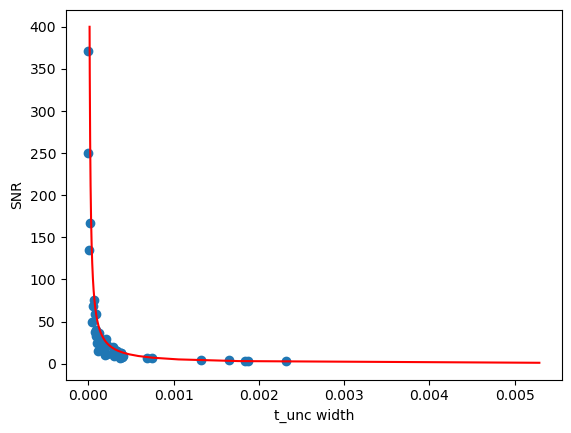

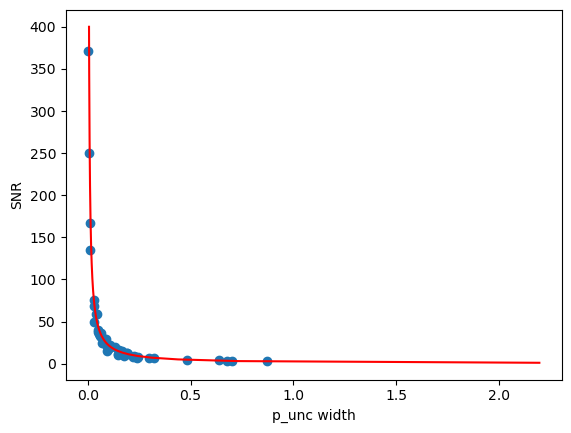

In [ ]:
# Plotting traing data and fits

plt.scatter(t_stds, snrs)
plt.plot(t_model,snr_range, color="red")
plt.xlabel("t_unc width")
plt.ylabel("SNR")
plt.show()

plt.scatter(p_stds, snrs)
plt.plot(p_model,snr_range, color="red")
plt.xlabel("p_unc width")


plt.ylabel("SNR")
plt.show()

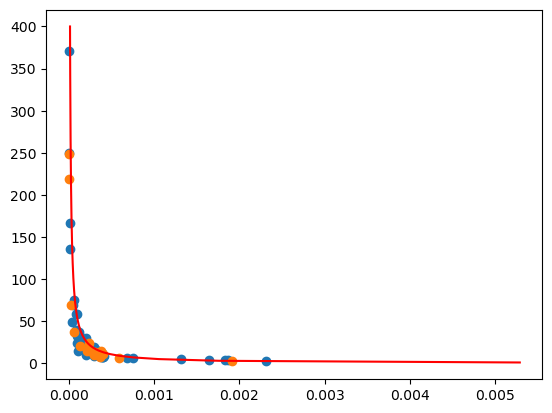

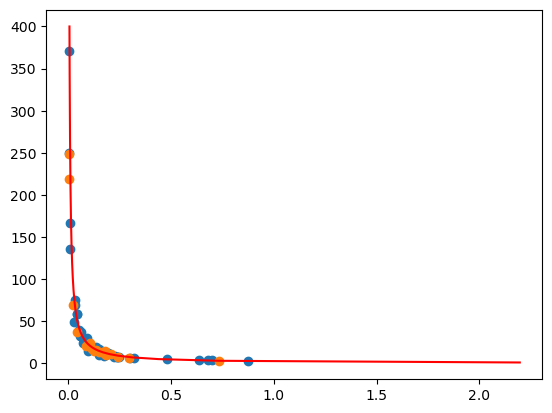

In [ ]:
# Now plot validation data against the training fit

val_t_stds = np.array([np.std(t) for (t,_,_,_) in validation_arrays.values()])
val_p_stds = np.array([np.std(p) for (_,p,_,_) in validation_arrays.values()])
val_snrs = np.array([s[0] for (_,_,_,s) in validation_arrays.values()])
plt.scatter(t_stds, snrs)
plt.scatter(val_t_stds,val_snrs)

plt.plot(t_model,snr_range, color="red")
plt.show()
# plt.scatter(p_stds, snrs)
plt.scatter(val_p_stds,val_snrs)

plt.plot(p_model,snr_range, color="red")
plt.show()

In [ ]:
# Checking model values for validation data to see how well they match training fit

a, b, std, lr_t  = tp.fit_std_vs_inv_snr(val_t_stds,  val_snrs, fit_intercept=False)
a2, b2, std2, lr_p = tp.fit_std_vs_inv_snr(val_p_stds, val_snrs, fit_intercept=False)
print("t-std fit:", b)
print("p-std fit:", b2)

t-std fit: 0.004826247341140522 0.00032541816612280714
p-std fit: 2.1862341868561184 0.05682435594425707


In [ ]:
# For phase unceratinty, the validation fit is close to the training fit and the model fits well to the data.
# For time unceratinity the model does not fit well at moderate SNRs. As there is additional dependence on bandwdith.